Evaluating model ..\output_results\E_pos\win\upos-snn_2026-05-13_12-49-37_e-50_s-20_spatial.pt Limit: 1
Evaluation | samples=9 | loss=7.7914 | acc=0.0000 | eval_time_ms=65.86
Average AC operations per sample: 164910.11
Average energy per sample: 4226645.78 pJ
Evaluating model ..\output_results\E_pos\seq\upos-seq_2026-05-13_14-06-16_e-50_s-20_spatial.pt Limit: 1
Evaluation | samples=1 | loss=1.2029 | acc=0.5556 | eval_time_ms=150.50
Average AC operations per sample: 58385.78
Average energy per sample: 1496427.44 pJ
ANN layer neurons [500, 17]
ANN layer neurons [2000, 256, 128, 17]


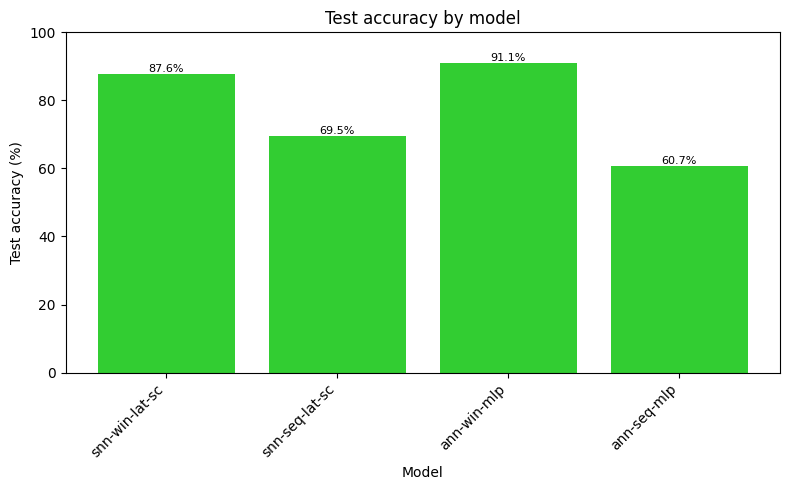

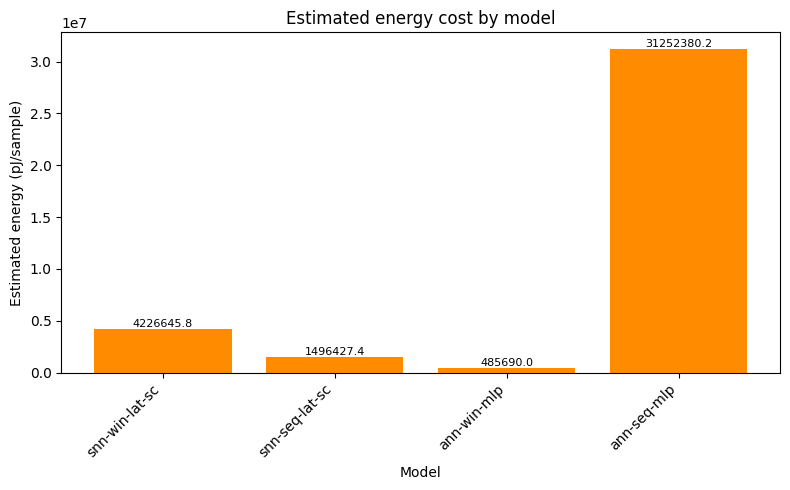

Saved TSV summary to ..\output_results\E_pos\upos_eval_summary.tsv


In [ ]:
import csv
import importlib
import json
from argparse import Namespace
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import E_pos_eval
import E_pos_seq_eval
from viz_util import colors, ModelNameConvention
from ann_util import calculate_ann_total_energy

evaluate_win = E_pos_eval.evaluate_model
evaluate_seq = E_pos_seq_eval.evaluate_model

win_snn_models = sorted(glob('../output_results/E_pos/win/*.pt'))
seq_snn_models = sorted(glob('../output_results/E_pos/seq/*.pt'))
win_ann_models = sorted(glob('../output_results/E_pos/win-mlp/*.pt'))
seq_ann_models = sorted(glob('../output_results/E_pos/seq-mlp/*.pt'))

model_groups = [
    ('snn_win', win_snn_models, evaluate_win),
    ('snn_seq', seq_snn_models, evaluate_seq),
    ('ann_win', win_ann_models, None),
    ('ann_seq', seq_ann_models, None),
]

records = []

def as_int(v):
    try:
        return int(v) if v is not None else None
    except Exception:
        try:
            return int(float(v))
        except Exception:
            return None

for group_name, paths, evaluator in model_groups:
    for model_path in paths:
        model_path = Path(model_path)
        meta_path = model_path.with_suffix('.json')
        if not meta_path.exists():
            print(f'Warning: metadata missing for {model_path}, skipping')
            continue

        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        training_config = meta.get('training_config', {}) or {}
        results = meta.get('results', {}) or {}
        train_accuracy_values = results.get('epoch_train_accuracy', [])
        train_accuracy = train_accuracy_values[-1] if train_accuracy_values else None

        # label for plots
        label_parts = [group_name]
        if group_name.startswith('ann'):
            label_parts.append('mlp')
        # else:
        #     label_parts.append('ann-mlp')
        # label_parts.append(str(training_config.get('input_mode', 'unknown')) if training_config else 'unknown')
        label_parts.append(str(training_config.get('encoding_method', '')) if training_config else '')
        label_parts.append(str(training_config.get('decoding_method', '')) if training_config else '')
        # label_parts.append(str(training_config.get('embedding_dimension', 100)) if training_config else '')
        # label_parts.append(str(training_config.get('output_file_prefix') or training_config.get('output_file_prefix', '') or model_path.stem))
        label = '-'.join([p for p in label_parts if p])
        try:
            label = ModelNameConvention(label)
        except Exception:
            pass

        test_accuracy = results.get('test_accuracy')

        energy_pj = None
        if evaluator is not None:
            # SNN: call appropriate evaluator (win or seq)
            eval_config = dict(training_config)
            eval_config.update({
                'model_path': str(model_path),
                'split': 'test',
                # 'limit': 1,
                'limit': None,
                'estimate_energy': True,
                'energy_ac_cost_pj': float(training_config.get('energy_ac_cost_pj') or training_config.get('energy_ac_cost_pj', 25.63) or 25.63),
                'diagnose': False,
                'output_json': None,
            })
            eval_args = Namespace(**eval_config)
            eval_results = evaluator(eval_args) or {}
            if test_accuracy is None:
                test_accuracy = eval_results.get('eval_accuracy')
            energy_pj = eval_results.get('avg_energy_pj_per_sample')
        else:
            # ANN: compute energy from architecture in training_config or model_config
            # Try to infer neuron counts per layer
            # First try explicit keys
            input_size = as_int(training_config.get('input_size') or training_config.get('input_dim') or training_config.get('embedding_dim'))
            # If embedding_dim provided along with sequence_length/window, compute input_size
            if input_size is None:
                seq_len = as_int(training_config.get('sequence_length') or training_config.get('window_size'))
                emb = as_int(training_config.get('embedding_dim'))
                if seq_len is not None and emb is not None:
                    input_size = seq_len * emb
            hidden1 = as_int(training_config.get('num_hidden_1') or training_config.get('hidden_size_1') or training_config.get('num_hidden'))
            hidden2 = as_int(training_config.get('num_hidden_2') or training_config.get('hidden_size_2'))
            output_size = as_int(training_config.get('output_size') or training_config.get('num_labels') or training_config.get('num_classes'))
            neurons = []
            if input_size is not None:
                neurons.append(input_size)
            if hidden1 is not None:
                neurons.append(hidden1)
            if hidden2 is not None:
                neurons.append(hidden2)
            if output_size is not None:
                neurons.append(output_size)

            print('ANN layer neurons', neurons)
            if len(neurons) >= 2:
                try:
                    energy_pj = calculate_ann_total_energy(neurons) #already has default emac energy per MAC in ann_util
                except Exception as e:
                    print(f'ANN energy calc failed for {model_path}: {e}')
                    energy_pj = None
            else:
                print(f'Insufficient architecture info for ANN {model_path}; neurons={neurons}')

        records.append({
            'label': label,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'energy_pj_per_sample': energy_pj,
        })

if not records:
    raise RuntimeError('No evaluation records were generated')

summary_dir = Path('../output_results/E_pos')
summary_dir.mkdir(parents=True, exist_ok=True)
tsv_path = summary_dir / 'upos_eval_summary.tsv'

with tsv_path.open('w', encoding='utf-8', newline='') as f:
    f.write('Model\tTrain accuracy\tTest accuracy\tEnergy (pJ/sample)\n')
    for rec in records:
        label = rec.get('label', '')
        train = float(rec.get('train_accuracy'))
        test = float(rec.get('test_accuracy'))
        energy = int(rec.get('energy_pj_per_sample'))
        f.write(f"{label}\t{train*100:.2f}\t{test*100:.2f}\t{energy}\n")

labels = [record['label'] for record in records]
test_accuracies = [record['test_accuracy'] for record in records]
energy_costs = [record['energy_pj_per_sample'] for record in records]

positions = np.arange(len(labels))

fig1, ax1 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
bars_acc = ax1.bar(positions, np.array(test_accuracies, dtype=float) * 100.0, color=colors.time)
ax1.set_xlabel('Model')
ax1.set_ylabel('Test accuracy (%)')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_ylim(0, 100)
ax1.set_title('Test accuracy by model')
for bar, value in zip(bars_acc, test_accuracies):
    if value is None:
        continue
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value * 100.0:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
bars_energy = ax2.bar(positions, energy_costs, color=colors.energy)
ax2.set_xlabel('Model')
ax2.set_ylabel('Estimated energy (pJ/sample)')
ax2.set_xticks(positions)
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.set_title('Estimated energy cost by model')
for bar, value in zip(bars_energy, energy_costs):
    if value is None:
        continue
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Saved TSV summary to {tsv_path}')